#### CAN MIRGU Exploratory Data Analysis

Understanding the structure of the dataset files, build the correct data format for the training of the model and validate 
with the metadata the attacks and benign messages. 

The CAN MIRGU attack data is organized into three folders by attack technique: 

- Masquerade Attacks (the attacker silences the real ECU and transmits the target ID at its normal rate with fake payloads) 
- Real Attacks (injection attacks where messages are added on top of normal traffic) 
- Suspension Attacks (the attacker stops a real ECU from transmitting, so the real ID gets ignored) 

The Masquerade and Suspension folders will not be used in this project, since both produce attacks with normal message timing and frequency, which do not match the structure of the feature vector proposed. Masquerade attacks transmit at the legitimate message rate, producing no inter arrival anomaly for a timing aware model to detect. On the other hand Suspension attacks represent a different structure detection problem since the analysis will follow the absence of messages rather than injected ones. The Real attacks folder modify the sequential and timing patterns or the content of the CAN traffic which is the main idea behind the multiclass detection IDs. 


Each CAN message is represented by the following feature vector containing: 

- CAN ID (the message identifier in hex e.g 0x368)
- Payload bytes (the data field, zero padded to 8 bytes)
- DLC (data length code, the true number of payload bytes derived from the message)
- Δt (inter arrival time, the gap in seconds between the current message and the previous one. Which is used to compare to the metadata information in order to identify the attack from the rest of the data)


In [1]:
import json5 
import os
import re 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path 

In [2]:
BASE = Path("/Users/anita/Documents/TFM/SSL_CyberSecurity")

ATTACK_DIR = BASE / "Attack" / "Real_attacks"
METADATA_PATH = BASE / "Attacks_metadata.json"
DOS_LOG = ATTACK_DIR / "DoS_attack.log"

### Metadata Json File 

The metadata file stores the description in json of all the attacks carried out by the authors, each attack contains the following fields: 

- Name of the attack
- Description: The attack's observable effect on the vehicle and the recording timeline of the events, benign - attack - benign. 
- Elapsed seconds: Total duration of the whole recording. 
- Attack duration: How long the injection itself lasted. 
- Injected data string: The payload the attacker injected in hex. 
- Injected CAN ID: The CAN ID used for injection, for most attacks is a single ID, for fuzzing it is a placeholder meaning no fixed ID. 
- Injection time interval: The [start, end] timestamps (Unix epoch seconds) the exact time the injection ocurred. Any message whose timestamp falls inside this interval is an attack message. 
- Attack type: Indicated the attack was physically injected on a real vehicle. 
- Attack tecnique: How the attack was carried out. 

In [3]:
with open("/Users/anita/Documents/TFM/SSL_CyberSecurity/Attacks_metadata.json") as f: 
    metadata = json5.load(f) 

print("Number of attack entries:", len(metadata)) 
print("Attack names:", list(metadata.keys())) 

Number of attack entries: 36
Attack names: ['Fuzzing_random_IDs', 'Fuzzing_valid_IDs', 'Steering_angle_replay', 'Steering_angle_attack', 'Steering_angle_masquerade_attack', 'Brake_and_fog_light_attack', 'Brake_and_fog_light_masquerade_attack', 'Brake_warning_attack', 'Brake_warning_masquerade_attack', 'Drive_mode_changing_attack', 'FCA_warning_attack', 'Power_steering_attack', 'Max_speedometer_attack', 'Min_speedometer_attack_1', 'Min_speedometer_masquerade_attack_1', 'Min_speedometer_attack_2', 'Min_speedometer_attack_3', 'Wiper_warning_attack', 'Wiper_warning_masquerade_attack', 'EMS_attack', 'EMS_replay_attack', 'EMS_replay_long_attack', 'Parking_brake_attack', 'DoS_attack', 'Gear_shifter_attack_1', 'Gear_shifter_attack_2', 'Door_open_warning_attack', 'Fuzzing_valid_IDs_and_DoS_attack', 'Reverse_speedometer_and_fuzzing_attack', 'Multiple_attacks_1', 'Multiple_attacks_2', 'ID_160_suspension_attack', 'ID_371_suspension_attack', 'ID_386_suspension_attack', 'ID_541_suspension_attack', '

In [4]:
metadata["DoS_attack"]

{'description': 'normal driving; start injecting; No visible changes ; stop injecting; normal driving',
 'elapsed_sec': 173.894856,
 'attack_duration': 90.76684,
 'injection_data_str': 'FFFFFFFFFFFFFFFF',
 'injection_CAN_id': '0x000',
 'injection_interval': [1698319591.695248, 1698319682.462088],
 'attack_type': 'real',
 'attack_technique': 'injecting every 0.001s'}

In [5]:
rows = [] 

for name, m in metadata.items(): 
    iv = m.get("injection_interval") 
    rows.append({
    "attack": name, 
    "technique": m.get("attack_technique"), 
    "can_id": m.get("injection_CAN_id"), 
    "duration_s": m.get("attack_duration"), 
    "has interval": iv is not None, 
    })
    
pd.DataFrame(rows) 

,attack,technique,can_id,duration_s,has interval
0,Fuzzing_random_IDs,injecting every 0.02s,XXX,153.704584,True
1,Fuzzing_valid_IDs,injecting every 0.02s,XXX,29.144068,True
2,Steering_angle_replay,flam,0x2B0,100.940543,True
3,Steering_angle_attack,flam,0x2B0,62.802738,True
4,Steering_angle_masquerade_attack,masquerade,None,62.802738,False
5,Brake_and_fog_light_attack,flam,0x07F,152.000010,True
6,Brake_and_fog_light_masquerade_attack,masquerade,None,152.000010,False
7,Brake_warning_attack,flam,0x160,137.053789,True
8,Brake_warning_masquerade_attack,masquerade,None,137.053789,False
9,Drive_mode_changing_attack,injecting every 0.02s,0x50C,72.921273,True


##### Data Structure / DoS file analysis

METADATA DESCRIPTION OF DoS: normal driving; start injecting; No visible changes ; stop injecting; normal driving

Raw line, the first line from the log file 

In [6]:
with open(DOS_LOG) as f:
    raw_line = f.readline().rstrip()

raw_line

'(1698319517.908320) can0 500#01 0'

Timestamp: extracts the float between ( and )

In [7]:
start = raw_line.index("(") + 1
end = raw_line.index(")")
timestamp = float(raw_line[start:end])
timestamp

1698319517.90832

Interface: first token after closing parenthesis 

In [8]:
after_timestamp = raw_line.split(") ", 1)[1]
interface = after_timestamp.split()[0]
interface

'can0'

CAN ID: Hex ID before # 

In [9]:
id_and_payload = after_timestamp.split()[1]
can_id = id_and_payload.split("#", 1)[0]
can_id

'500'

Payload: Hex bytes after #

In [10]:
payload = id_and_payload.split("#", 1)[1]
payload

'01'

Flag: trailing integer (0 benign, 1 injected)

In [11]:
flag = int(after_timestamp.split()[2])
flag

0

DLC from payload 

In [12]:
dlc = len(payload) // 2 
print("payload hex:", payload, "DLC:", dlc)

payload hex: 01 DLC: 1


Pad the payload to 8 bytes since different IDs carry different data lengths. Dropping them would delete whole ECUs and break the sequence. 

In [13]:
payload_bytes = []

for i in range (0, len(payload), 2): 
    payload_bytes.append(payload[i:i+2])
    
while len(payload_bytes) < 8: 
    payload_bytes.append("00")
    
print("payload bytes:", payload_bytes)

payload bytes: ['01', '00', '00', '00', '00', '00', '00', '00']


In [14]:
def extract_can_fields(line):
    pattern = r"\((.*?)\)\s+(\S+)\s+([0-9A-Fa-f]+)#([0-9A-Fa-f]*)\s*(\d*)"
    match = re.match(pattern, line)
    
    if not match: 
        return None 
    
    timestamp, interface, can_id, payload, flag= match.groups()
    
    dlc = len(payload) // 2
    
    payload_bytes = []

    for i in range (0, len(payload), 2): 
        payload_bytes.append(payload[i:i+2])
    
    while len(payload_bytes) < 8: 
        payload_bytes.append("00")
        
    return {
        "timestamp": float(timestamp), 
        "interface": interface, 
        "can_id": can_id, 
        "payload": payload_bytes, 
        "dlc": dlc, 
        "flag": int(flag) if flag else 0, 
    }

In [15]:
rows = []

for line in open(DOS_LOG): 
    row = extract_can_fields(line)
    
    if row: 
        rows.append(row)
        
df = pd.DataFrame(rows)

df["dt"] = df["timestamp"].diff().fillna(0)

df.head()

,timestamp,interface,can_id,payload,dlc,flag,dt
0,1.698320e+09,can0,500,"[01, 00, 00, 00, 00, 00, 00, 00]",1,0,0.000000
1,1.698320e+09,can0,130,"[48, 76, 70, 7A, 00, 00, 0F, A8]",8,0,0.001079
2,1.698320e+09,can0,140,"[B6, 80, 00, 65, 20, 00, 0F, 88]",8,0,0.000002
3,1.698320e+09,can0,340,"[13, 00, 00, 04, 00, 20, 48, 11]",8,0,0.001507
4,1.698320e+09,can0,153,"[20, 80, 10, FF, 00, FF, 20, CE]",8,0,0.001825


In [16]:
df.shape

(341787, 7)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341787 entries, 0 to 341786
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   timestamp  341787 non-null  float64
 1   interface  341787 non-null  object 
 2   can_id     341787 non-null  object 
 3   payload    341787 non-null  object 
 4   dlc        341787 non-null  int64  
 5   flag       341787 non-null  int64  
 6   dt         341787 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 18.3+ MB


Shows that all columns contain 341,787 non null values, indicating that no messages were lost during parsing and that there are no missing values in the dataset. This confirms that the data extraction process was successful. 

In [18]:
df["can_id"].value_counts().head(10)

can_id
140    17393
130    17393
251    17389
372    17389
340    17389
153    17389
160    17389
164    17389
220    17389
371    17389
Name: count, dtype: int64

The most frequent CAN IDs each appear approximately 17,390 times throughout the capture. The fact that these messages counts are nearly identical suggests that these frames are generated by legitimate vehicle Electronic Control Units (ECUs) transmitting at fixed rates. 

In [19]:
df["dt"].mean()

np.float64(0.0005087813637619475)

The average inter arrival time between consecutive CAN frames is approximately 0.509 milliseconds. This corresponds to a message rate of roughly 1,965 frames per second, indicating a heavily utilized CAN bus. This result is consistent with the metadata description of the attack, which states that malicious messages were injected every 0.001 seconds. Therefore reflects a combination of normal vehicle traffic and additional traffic generated during the DoS attack period. 

In [20]:
df["timestamp"].max() - df["timestamp"].min()

173.89485597610474

The traffic was captured over a period of approximately 173.9 seconds, which matches the elapsed_sec field provided by the metadata file confirming that the timestamps were correctly parsed and that the log corresponds to the metadata description. 

This validation is important to demonstrate that the temporal information contained in the CAN log aligns with the ground truth attack information. 

<Axes: xlabel='can_id'>

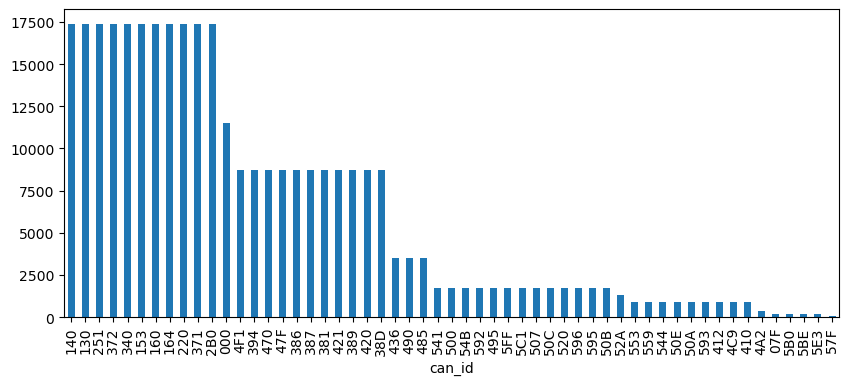

In [21]:
df["can_id"].value_counts().plot.bar(figsize=(10,4))

In [22]:
start, end = metadata["DoS_attack"]["injection_interval"]
df["label"] = np.where((df.timestamp>=start)&(df.timestamp<=end), "DoS", "Benign")

In [23]:
print(df["label"].value_counts())
print("\n0x000 OUTSIDE interval:", ((df.can_id=="000")&(df.label=="Benign")).sum())
print("0x000 INSIDE interval :", ((df.can_id=="000")&(df.label=="DoS")).sum())

label
DoS       183911
Benign    157876
Name: count, dtype: int64

0x000 OUTSIDE interval: 0
0x000 INSIDE interval : 11533


 ~54% attack-labelled, ~46% benignk, indicating than half of the captured traffic was recorded while the attack was active. 


Outside the attack window, 0x000 appears 0 times. 
Inside the window, 0x000 appears 11,533 times, meaning that every single occurrence of the injected ID falls inside the labelled interval. 

We are doing the labelling of time windows, not individual malicious messages. A row is DoS if it occurred during the attack, not because that specific message is injected. 

[A window is labelled attack if >= 1 of its messages falls in the attack interval (or contains the injected ID)]

### Unique CAN IDs - DoS Attack 

In [24]:
name = "DoS_attack"
path = ATTACK_DIR / f"{name}.log"

unique_can_ids = set()
with open(path) as f:
    for line in f:
        extracted = extract_can_fields(line)
        if extracted is not None:
            unique_can_ids.add(extracted["can_id"])

print(f"{name}: {len(unique_can_ids)} unique CAN IDs")
print(sorted(unique_can_ids))

DoS_attack: 55 unique CAN IDs
['000', '07F', '130', '140', '153', '160', '164', '220', '251', '2B0', '340', '371', '372', '381', '386', '387', '389', '38D', '394', '410', '412', '420', '421', '436', '470', '47F', '485', '490', '495', '4A2', '4C9', '4F1', '500', '507', '50A', '50B', '50C', '50E', '520', '52A', '541', '544', '54B', '553', '559', '57F', '592', '593', '595', '596', '5B0', '5BE', '5C1', '5E3', '5FF']


### Spoofing Attacks DataFrame + Parser 

In [25]:
ATTACKS = {
    "Steering_angle_attack": "Spoofing", 
    "Brake_warning_attack": "Spoofing", 
    "Power_steering_attack": "Spoofing", 
    "Min_speedometer_attack_1": "Spoofing", 
    "EMS_replay_attack": "Replay", 
    "Steering_angle_replay": "Replay", 
    "Fuzzing_random_IDs": "Fuzzing", 
    "Fuzzing_valid_IDs": "Fuzzing", 
    "DoS_attack": "DoS",
}

In [26]:
def load_attack_file(name): 
    meta = metadata[name]
    attack_class = ATTACKS[name]
    
    
    path = ATTACK_DIR / f"{name}.log"
    
    rows = []
    with open(path) as f: 
        for line in f: 
            extracted = extract_can_fields(line)
            if extracted is not None: 
                rows.append(extracted)
                
    df = pd.DataFrame(rows)
    
    df["dt"] = df["timestamp"].diff().fillna(0.0)
    
    df["id_int"] = [int(x,16) for x in df["can_id"]]
    
    start, end = meta["injection_interval"]
    
    mask = (
        (df["timestamp"] >= start) & 
        (df["timestamp"] <= end)
    )
    
    df["label"] = "Benign"
    df.loc[mask, "label"] = attack_class
    
    return df 
    

Helper function to load the attack files inside the Real Attacks file from the CAN MIRGU dataset stored locally. 

In [27]:
with open(METADATA_PATH) as f: 
    metadata = json5.load(f)
    
print("Number of attack entries:", len(metadata))
print("Attack_names:", list(metadata.keys())[:10])

Number of attack entries: 36
Attack_names: ['Fuzzing_random_IDs', 'Fuzzing_valid_IDs', 'Steering_angle_replay', 'Steering_angle_attack', 'Steering_angle_masquerade_attack', 'Brake_and_fog_light_attack', 'Brake_and_fog_light_masquerade_attack', 'Brake_warning_attack', 'Brake_warning_masquerade_attack', 'Drive_mode_changing_attack']


### Spoofing 

Inside the spoofing attacks we will be analysing the following: 

- Steering_angle_attack
- Brake_warning_attack
- Power_steering_attack 
- Min_speedometer_1 

In a spoofing attack, they inject messages using an ID that a legitimate part of the car is already using. Because both the real car part and the attacker are broadcasting the same ID, at the same time during the attack window, there is a massive frequency increase in how often the ID appears. So we need to calculate the **rate messages per second**, **msg/s**. 

#### Steering Angle Attack

Steering angle attack consist on the manipulation of the steering angle signal, which is the data that controls how much the front wheels are turning. 

Many safety systems depend on accurate steering angle data. If the data is wrong, the car behaves unpredictably. 

It can cause: 

- Unstable traction and stability control (ESC)
ESC uses steering angle to decide how to correct skids, fake data can cause: braking the wrong wheel, incorrect torque distribution, sudden unsafe corrections. 

- Malfunctioning driver assistance systems

Systems like: 
- Lane keeping assist 
- Lane departure warning 
- Steering assist 
- Parking assist 

- Erratic electric prower steering behavior: in vehicles with electric steering assist, the motor may apply force unexpectedly. Can cause loss of control during driving, which can make the vehicle turn more than intended, fail to turn, jerk the steering, drift out of the lane. 

Potential accidents: in extreme cases the vehicle can become unstable and veer off course. 

METADATA DESCRIPTION: normal driving; start injecting; 'Check FCA(Forward Coll Avoidance Assist)' warning message and sound, 'Cruise Fault: Restart the car to engage' warning message on lane detection display; stop injecting; normal driving.

In [53]:
name = "Steering_angle_attack"
df = load_attack_file(name)

raw = metadata[name]["injection_CAN_id"]
inj = int(raw, 16)

out = df[df.label == "Benign"]
ins = df[df.label != "Benign"]

start, end = metadata[name]["injection_interval"]
dur_out = (start - df.timestamp.min()) + (df.timestamp.max() - end)
dur_in  = end - start

out_rate = (out.id_int == inj).sum() / dur_out
ins_rate = (ins.id_int == inj).sum() / dur_in
print(f"OUTSIDE: {out_rate: .1f} msg/s INSIDE: {ins_rate: .1f} msg/s  Spike: {ins_rate/out_rate: .2f}x")


OUTSIDE:  100.0 msg/s INSIDE:  200.0 msg/s  Spike:  2.00x


In [29]:
df = df.drop(columns=["interface"])
df.head()

,timestamp,can_id,payload,dlc,flag,dt,id_int,label
0,1.698234e+09,381,"[80, 90, 37, 00, 00, 80, CC, 05]",8,0,0.000000e+00,897,Benign
1,1.698234e+09,251,"[A6, 02, 00, D8, 00, F2, C6, 78]",8,0,1.019955e-03,593,Benign
2,1.698234e+09,2B0,"[4E, FE, 00, 07, C0, 00, 00, 00]",5,0,9.536743e-07,688,Benign
3,1.698234e+09,4F1,"[20, 3B, 66, E0, 00, 00, 00, 00]",4,0,9.536743e-07,1265,Benign
4,1.698234e+09,592,"[50, EF, 19, 00, 00, 02, 47, 48]",8,0,9.536743e-07,1426,Benign


Outside the real steering angle ECU sends 0x2B0 at 67 msg/s having a normal periodic rate. 
Inside the rate jumps to 200 msg/s meaning the attacker's injected messages stacked on top of the real ECU. 

For a flam attack a spike of 2.99 means that the attacker injects faster than the real ECU so the fake values appear the most recent. Meaning that the fake messages run 2x the legitimate rate on top of the original messages. Which is exactly how fabrication attacks decieve the receiving ECUs. 

By converting the CAN IDs from hexadecimals into integers we make sure there are no conflicts on how the data is being presented, since different files can have different hex formats. Standard CAN IDs can be represented as 7F or padded to three digits 07F, as strings this would give a comparison error but as integers 127 == 127 would perfectly match. 

At the same time ML models can not read string data, by transforming the IDs into integers it ensures the DataFrame is 100% numerical and ready for the training. 

On the other hand strings are more computationally expensive since strings are objects data types, they consume massive amounts of RAM and force python to check character by character bytes. Integers int64 or int16 are processed much faster. 

In [30]:
malicious_df = df[df["label"] != "Benign"]

print(f"Total malicious rows: {len(malicious_df)}")
malicious_df.head()

Total malicious rows: 126189


,timestamp,can_id,payload,dlc,flag,dt,id_int,label
135956,1.698234e+09,2B0,"[F6, AA, 00, 07, 2C, 00, 00, 00]",5,1,9.479523e-04,688,Spoofing
135957,1.698234e+09,130,"[98, 7F, DA, 7E, 00, 00, 04, E2]",8,0,1.049042e-03,304,Spoofing
135958,1.698234e+09,140,"[7D, 7F, 00, 64, 20, 00, 04, 99]",8,0,9.536743e-07,320,Spoofing
135959,1.698234e+09,495,"[00, 00, 0D, 10, F5, B0, 2E, A7]",8,0,0.000000e+00,1173,Spoofing
135960,1.698234e+09,371,"[00, 1E, 00, 80, 91, 11, 00, 10]",8,0,1.155138e-03,881,Spoofing


Looking at the dataframe, we can observe that the flag column represents the CAN frame type flag recorded by the physical sniffing tool. 

0 = Standard Data Frame which is the normal broadcast message containing the 11 bit ID and up to 8 bytes of data payload. 
1 = Error Frame meaning the car's physical CAN controller detected an electrical collision, a broken wire or a checksum mismatch. 
2 = Remote Transmission Request (RTR) meaning one ECU is specifically asking another ECU to send its data. 

Spoofing attacks sends perfectly formatted data, mathematically valid messages so the logging hardware just sees the standard electrical broadcast. Since CAN bus networks do not have built in encryption or sender authentication the car's physical network cannot tell the difference between the legitimate Power Steering ECU or an attacker's laptop. For the physical wire both look identical this is the reason why the main detection is on the frequency spike data. 

### Unique CAN IDs — Steering Angle Attack

In [31]:
name = "Steering_angle_attack"
path = ATTACK_DIR / f"{name}.log"

unique_can_ids = set()
with open(path) as f:
    for line in f:
        extracted = extract_can_fields(line)
        if extracted is not None:
            unique_can_ids.add(extracted["can_id"])

print(f"{name}: {len(unique_can_ids)} unique CAN IDs")
print(sorted(unique_can_ids))

Steering_angle_attack: 56 unique CAN IDs
['07F', '130', '140', '153', '160', '164', '220', '251', '2B0', '340', '371', '372', '381', '386', '387', '389', '38D', '394', '410', '412', '420', '421', '436', '470', '47F', '485', '490', '495', '4A2', '4A7', '4C9', '4F1', '500', '507', '50A', '50B', '50C', '50E', '520', '52A', '53E', '541', '544', '54B', '553', '559', '57F', '592', '593', '595', '596', '5B0', '5BE', '5C1', '5E3', '5FF']


#### Brake Warning Attack

A brake warning attack consist of forging CAN messages that tell the dashboard or safety systems that the brakes are failing, overheating or malfunctioning, even when the braking system is perfectly fine. 

The attacker can inject false messages such as: 

- ABS failure 
- Brake pressure low 
- Brake system overheating 
- Emergency brake fault

- Driver panic and unsafe reactions 

A sudden brake warning can cause the driver to: abruptly slow down, pull over in traffic, lose focus, make unsafe maneuvers. Dangerous at high speeds or in dense traffic. 

- Automatic safety systems may intervene incorrectly: disable ABS or ESC, apply emergency braking unnecessaril, reduce engine power, enter limp mode. 

- Loss of trust in vehicle warnings: repeated false warnings can cause drivers to ignore real brake failures later, a long term safety risk. 

- Potential for coordinated multi system disruption: traction control, stability control, collision avoidance, adaptative cruise control. 

METADATA DESCRIPTION: normal driving; start injecting; 'Stop vehicle and check brakes' warning message and sound; stop injecting; normal driving

In [54]:
name = "Brake_warning_attack"
df = load_attack_file(name)

raw = metadata[name]["injection_CAN_id"]
inj = int(raw, 16)

out = df[df.label == "Benign"]
ins = df[df.label != "Benign"]

start, end = metadata[name]["injection_interval"]
dur_out = (start - df.timestamp.min()) + (df.timestamp.max() - end)
dur_in  = end - start

out_rate = (out.id_int == inj).sum() / dur_out
ins_rate = (ins.id_int == inj).sum() / dur_in

print(f"OUTSIDE: {out_rate: .1f} msg/s INSIDE: {ins_rate: .1f} msg/s  Spike: {ins_rate/out_rate: .2f}x")

OUTSIDE:  100.0 msg/s INSIDE:  179.8 msg/s  Spike:  1.80x


### Unique CAN IDs — Brake Warning Attack

In [33]:
name = "Brake_warning_attack"
path = ATTACK_DIR / f"{name}.log"

unique_can_ids = set()
with open(path) as f:
    for line in f:
        extracted = extract_can_fields(line)
        if extracted is not None:
            unique_can_ids.add(extracted["can_id"])

print(f"{name}: {len(unique_can_ids)} unique CAN IDs")
print(sorted(unique_can_ids))

Brake_warning_attack: 56 unique CAN IDs
['07F', '130', '140', '153', '160', '164', '220', '251', '2B0', '340', '371', '372', '381', '386', '387', '389', '38D', '394', '410', '412', '420', '421', '436', '470', '47F', '485', '490', '495', '4A2', '4A7', '4C9', '4F1', '500', '507', '50A', '50B', '50C', '50E', '520', '52A', '53E', '541', '544', '54B', '553', '559', '57F', '592', '593', '595', '596', '5B0', '5BE', '5C1', '5E3', '5FF']


#### Power Steering Attack 

A spoofing attack where an attacker injects CAN messages that manipulate the behavior of the Electric Power Steering (EPS) system. By sending fake steering assist or torque related signals, the attacker can cause the steering to become unexpectedly heavy, overly sensitive or erratic. Compromising the drivers ability to control the vehicle. 

- Steering angle: Steering angle sensor module 
- Steering torque: Driver input force 
- Vehicle speed: assist decreases at high speed 
- Drive mode settings: sport = stiff, comfort = soft 

- Fake torque values 
- Fake assist level commands 
- Fake steering related status message 
- Override real sensor data 


METADATA DESCRIPTION: normal driving; start injecting; 'Check motor driven power steering' warning message, slightly less control of the steering wheel ; stop injecting; normal driving



In [55]:
name = "Power_steering_attack"
df = load_attack_file(name)

raw = metadata[name]["injection_CAN_id"]
inj = int(raw, 16)

out = df[df.label == "Benign"]
ins = df[df.label != "Benign"]

start, end = metadata[name]["injection_interval"]
dur_out = (start - df.timestamp.min()) + (df.timestamp.max() - end)
dur_in  = end - start

out_rate = (out.id_int == inj).sum() / dur_out
ins_rate = (ins.id_int == inj).sum() / dur_in
print(f"OUTSIDE: {out_rate: .1f} msg/s INSIDE: {ins_rate: .1f} msg/s  Spike: {ins_rate/out_rate: .2f}x")

OUTSIDE:  50.0 msg/s INSIDE:  100.0 msg/s  Spike:  2.00x


#### Unique CAN IDs — Power Steering Attack

In [35]:
name = "Power_steering_attack"
path = ATTACK_DIR / f"{name}.log"

unique_can_ids = set()
with open(path) as f:
    for line in f:
        extracted = extract_can_fields(line)
        if extracted is not None:
            unique_can_ids.add(extracted["can_id"])

print(f"{name}: {len(unique_can_ids)} unique CAN IDs")
print(sorted(unique_can_ids))

Power_steering_attack: 56 unique CAN IDs
['07F', '130', '140', '153', '160', '164', '220', '251', '2B0', '340', '371', '372', '381', '386', '387', '389', '38D', '394', '410', '412', '420', '421', '436', '470', '47F', '485', '490', '495', '4A2', '4A7', '4C9', '4F1', '500', '507', '50A', '50B', '50C', '50E', '520', '52A', '53E', '541', '544', '54B', '553', '559', '57F', '592', '593', '595', '596', '5B0', '5BE', '5C1', '5E3', '5FF']


#### Min_Speedometer_Attack_1

Forces the instrument cluster to display an unreallistic low vehicle speed even when the vehicle is moving normally. This attack manipulates the driver's perception of speed and can interfere with systems that depend on speed information. 

- Artificially low speed values 
- Zero speed values 
- Frozen speed values 
- Inconsistent speed patterns 


METADATA DESCRIPTION: normal driving; start injecting; speedometer jumps to 15 MPH while driving at 30 MPH; stop injecting; normal driving

In [56]:
name = "Min_speedometer_attack_1"
df = load_attack_file(name)

raw = metadata[name]["injection_CAN_id"]
inj = int(raw, 16)

out = df[df.label == "Benign"]
ins = df[df.label != "Benign"]

start, end = metadata[name]["injection_interval"]
dur_out = (start - df.timestamp.min()) + (df.timestamp.max() - end)
dur_in  = end - start

out_rate = (out.id_int == inj).sum() / dur_out
ins_rate = (ins.id_int == inj).sum() / dur_in

print(f"OUTSIDE: {out_rate: .1f} msg/s INSIDE: {ins_rate: .1f} msg/s  Spike: {ins_rate/out_rate: .2f}x")

OUTSIDE:  50.0 msg/s INSIDE:  100.0 msg/s  Spike:  2.00x


### Unique CAN IDs — Min Speedometer Attack 1

In [37]:
name = "Min_speedometer_attack_1"
path = ATTACK_DIR / f"{name}.log"

unique_can_ids = set()
with open(path) as f:
    for line in f:
        extracted = extract_can_fields(line)
        if extracted is not None:
            unique_can_ids.add(extracted["can_id"])

print(f"{name}: {len(unique_can_ids)} unique CAN IDs")
print(sorted(unique_can_ids))

Min_speedometer_attack_1: 54 unique CAN IDs
['07F', '130', '140', '153', '160', '164', '220', '251', '2B0', '340', '371', '372', '381', '386', '387', '389', '38D', '394', '410', '412', '420', '421', '436', '470', '47F', '485', '490', '495', '4A2', '4C9', '4F1', '500', '507', '50A', '50B', '50C', '50E', '520', '52A', '541', '544', '54B', '553', '559', '57F', '592', '593', '595', '596', '5B0', '5BE', '5C1', '5E3', '5FF']


#### Fuzzing 

Inside the fuzzing attacks we will be analysing the following: 

- Fuzzing random IDs: Injects random IDs meaning new IDs appear 
- Fuzzing Valid IDs: Injects legitimate IDs meaning the change happens on the frequency / timing of the messages 

[No single ID, label by interval]

##### Fuzzing Random IDs

METADATA DESCRIPTION: normal driving; start injecting; warning message on the dashboard and warning sounds; stop injecting; normal driving

In [38]:
name = "Fuzzing_random_IDs"
df = load_attack_file(name)

out = df[df.label == "Benign"]
ins = df[df.label != "Benign"]

out_ids = set(out.id_int.unique())
ins_ids = set(ins.id_int.unique())
new_ids = ins_ids - out_ids


print(f"IDs OUTSIDE: {len(out_ids)}")
print(f"IDs INSIDE: {len(ins_ids)}")
print(f"New IDs during the attack: {len(new_ids)}")
print(f"Examples: {sorted(f'0x{int(i):03X}' for i in new_ids)[:15]}")

injected = ins[ins.id_int.isin(new_ids)]
dur = ins.timestamp.max() - ins.timestamp.min()
print(f"Injected messages: {len(injected)}")
print(f"Attack duration: {dur:.1f} s   (metadata says 153.70)")
print(f"Injection rate: {len(injected)/dur:.1f} msg/s   (metadata implies ~50)")

IDs OUTSIDE: 56
IDs INSIDE: 646
New IDs during the attack: 590
Examples: ['0x000', '0x001', '0x002', '0x003', '0x004', '0x005', '0x006', '0x007', '0x008', '0x009', '0x00A', '0x00B', '0x00C', '0x00D', '0x00E']
Injected messages: 7458
Attack duration: 153.7 s   (metadata says 153.70)
Injection rate: 48.5 msg/s   (metadata implies ~50)


- IDs Outside represents the IDs during the normal traffic so approx 56 distinct CAN IDs. 
- IDs Inside represents the IDs during the attack approx 646 distinct CAN IDs. 
- 590 New IDs where generated during the attack, IDs that never occur in benign traffic. 

Looking at the bus rate that goes from 1133 msg/s to 1959 msg/s tells us there is a 73% increase in the traffic during injection and therefore increases the volume valdiating the metadata of "injecting every 0.02s"

The vehicle normally uses 56 IDs, the attacker then injects 590 new IDs that do not belong to any real ECU. 

#### Unique CAN IDs — Fuzzing Random IDs

In [39]:
name = "Fuzzing_random_IDs"
path = ATTACK_DIR / f"{name}.log"

unique_can_ids = set()
with open(path) as f:
    for line in f:
        extracted = extract_can_fields(line)
        if extracted is not None:
            unique_can_ids.add(extracted["can_id"])

print(f"{name}: {len(unique_can_ids)} unique CAN IDs")
print(sorted(unique_can_ids))

Fuzzing_random_IDs: 646 unique CAN IDs
['000', '001', '002', '003', '004', '005', '006', '007', '008', '009', '00A', '00B', '00C', '00D', '00E', '00F', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '01A', '01B', '01C', '01D', '01E', '01F', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '02A', '02B', '02C', '02D', '02E', '02F', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '03A', '03B', '03C', '03D', '03E', '03F', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '04A', '04B', '04C', '04D', '04E', '04F', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '05A', '05B', '05C', '05D', '05E', '05F', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '06A', '06B', '06C', '06D', '06E', '06F', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '07A', '07B', '07C', '07D', '07E', '07F', '080', '081', '082', '083', '084', '085', '086', '087', '088', '

#### Fuzzing Valid IDs 

METADATA DESCRIPTION: normal driving; start injecting; more warning message on the dashboard and warning sounds; stop injecting; normal driving

In [40]:
name = "Fuzzing_valid_IDs"
df = load_attack_file(name)
out = df[df.label=="Benign"]; ins = df[df.label!="Benign"]

start, end = metadata[name]["injection_interval"]
dur_out = (start - df.timestamp.min()) + (df.timestamp.max() - end)
dur_in  = end - start

rate_out = out.id_int.value_counts() / dur_out
rate_in  = ins.id_int.value_counts() / dur_in

spike = (rate_in / rate_out).sort_values(ascending=False)
print("Top rate-inflated IDs (inside/outside ratio):")
print(spike.head(10))

print(f"\nOverall bus rate OUT: {len(out)/dur_out:.0f}  IN: {len(ins)/dur_in:.0f} msg/s")

Top rate-inflated IDs (inside/outside ratio):
id_int
1322    3.305086
1287    1.505910
1168    1.257812
902     1.110263
593     1.067033
832     1.056397
688     1.053753
882     1.053309
356     1.049392
352     1.049292
Name: count, dtype: float64

Overall bus rate OUT: 1910  IN: 1961 msg/s


Random ID fuzzing injects 590 previously unseen identifiers and is trivially separable by ID novelty. Valid ID fuzzing, by contrast, introduces no new identifiers (0 new IDs) and is detectable only through frequency inflation of legitimate IDs demonstrating that ID based detection alone is insufficient and motivating a representation that jointly models identifier, timing, and payload information.

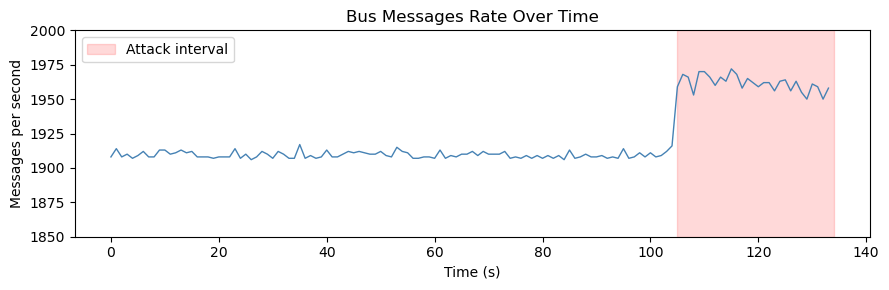

In [41]:
name = "Fuzzing_valid_IDs"
df = load_attack_file(name)
start, end = metadata[name]["injection_interval"]

t0 = df.timestamp.min()
df["t_rel"] = df.timestamp - t0
rate = df.groupby(df["t_rel"].astype(int)).size() 
rate = rate.iloc[:-1]  

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(rate.index, rate.values, lw=1, color="steelblue")
ax.axvspan(start - t0, end - t0, color="red", alpha=0.15, label="Attack interval")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Messages per second")
ax.set_ylim(1850, 2000) 
ax.set_title("Bus Messages Rate Over Time")
ax.legend()
plt.tight_layout()
plt.show()
    

#### Unique CAN IDs — Fuzzing Valid IDs

In [42]:
name = "Fuzzing_valid_IDs"
path = ATTACK_DIR / f"{name}.log"

unique_can_ids = set()
with open(path) as f:
    for line in f:
        extracted = extract_can_fields(line)
        if extracted is not None:
            unique_can_ids.add(extracted["can_id"])

print(f"{name}: {len(unique_can_ids)} unique CAN IDs")
print(sorted(unique_can_ids))

Fuzzing_valid_IDs: 56 unique CAN IDs
['07F', '130', '140', '153', '160', '164', '220', '251', '2B0', '340', '371', '372', '381', '386', '387', '389', '38D', '394', '410', '412', '420', '421', '436', '470', '47F', '485', '490', '495', '4A2', '4A7', '4C9', '4F1', '500', '507', '50A', '50B', '50C', '50E', '520', '52A', '53E', '541', '544', '54B', '553', '559', '57F', '592', '593', '595', '596', '5B0', '5BE', '5C1', '5E3', '5FF']


#### Replay 

Inside the replay attacks we will be analysing the following: 

- Steering angle replay

METADATA DESCRIPTION: normal driving; start injecting; no visible changes; stop injecting; normal driving

- EMS replay attack 

METADATA DESCRIPTION: normal driving; start injecting; No visible changes; stop injecting; normal driving

### Steering Angle Replay

In [43]:
name = "Steering_angle_replay"
df = load_attack_file(name)

out = df[df.label == "Benign"]
ins = df[df.label != "Benign"]

out_ids = set(out.id_int.unique())
ins_ids = set(ins.id_int.unique())
new_ids = ins_ids - out_ids


print(f"IDs OUTSIDE: {len(out_ids)}")
print(f"IDs INSIDE: {len(ins_ids)}")
print(f"New IDs during the attack: {len(new_ids)}")
print(f"Examples: {sorted(f'0x{int(i):03X}' for i in new_ids)[:15]}")

injected = ins[ins.id_int.isin(new_ids)]
dur = ins.timestamp.max() - ins.timestamp.min()
print(f"Injected messages: {len(injected)}")
print(f"Attack duration: {dur:.1f} s   (metadata says 100.94)")

IDs OUTSIDE: 56
IDs INSIDE: 56
New IDs during the attack: 0
Examples: []
Injected messages: 0
Attack duration: 100.9 s   (metadata says 100.94)


No new attacks are injected as seen on the fuzzing valid attack. 

The attacker is stacking replayed messages on top of real ECU's stream at more than twice its rate. 
Rate alone does not separate spoofing from replay alone, both attacks inflate the ID target by 3x. If a classifier only saw per ID rate, it could tell "attack vs benign" but not "spoofing vs replay". So the model has to look at payload in order to distinguish between this classes, not just at timing. 

We look at: 

1. How many payloads there are? 
2. How many distinct payloads exist?
3. The entropy (how unpredictable the payloads are)
4. The most common payload.
5. The share of the most common payload inside the dataset. 

Entropy is computed using the following formula: 

H=−∑pilog⁡2(pi)

Where pi is the probability of each payload. 

- High repetitive payloads = **low entropy**. 
- Highly varied paylaods = **high entropy**. 

In [57]:
name = "Steering_angle_replay"
df = load_attack_file(name)

raw = metadata[name]["injection_CAN_id"]
inj = int(raw, 16)

sub = df[df['id_int'] == inj].copy()
sub['payload_str'] = sub['payload'].apply("".join)

out = df[df.label == "Benign"]
ins = df[df.label != "Benign"]

start, end = metadata[name]["injection_interval"]
dur_out = (start - df.timestamp.min()) + (df.timestamp.max() - end)
dur_in  = end - start

out_rate = (out.id_int == inj).sum() / dur_out
ins_rate = (ins.id_int == inj).sum() / dur_in

def payload_stats(series):
    if series.empty:
        print("Empty Series")
        return
    
    counts = series.value_counts()
    
    p = counts / counts.sum()
    entropy = -(p * np.log2(p)).sum()
    
    print("Total Messages: ", len(series))
    print("Distinct payloads: ", len(counts))
    print("Entropy: ", round(entropy, 3))
    print("Most Common Payload: ", counts.index[0])
    print("Share of the most common: ", round(p.iloc[0], 3))
    
    
print(f"Target ID: {hex(inj)}")

print(f"OUTSIDE: {out_rate: .1f} msg/s INSIDE: {ins_rate: .1f} msg/s Spike: {ins_rate/out_rate: .2f}x")

benign_payloads = sub.loc[sub["label"] == "Benign", "payload_str"]
attack_payloads = sub.loc[sub["label"] != "Benign", "payload_str"]

print("\nBenign Traffic: ")
payload_stats(benign_payloads)

print("\nAttack Traffic: ")
payload_stats(attack_payloads)



Target ID: 0x2b0
OUTSIDE:  100.0 msg/s INSIDE:  200.0 msg/s Spike:  2.00x

Benign Traffic: 
Total Messages:  14290
Distinct payloads:  7558
Entropy:  12.315
Most Common Payload:  0800000769000000
Share of the most common:  0.002

Attack Traffic: 
Total Messages:  20189
Distinct payloads:  5625
Entropy:  6.987
Most Common Payload:  0700000755000000
Share of the most common:  0.5


In [58]:
name = "Steering_angle_attack"
df = load_attack_file(name)

raw = metadata[name]["injection_CAN_id"]
inj = int(raw, 16)

sub = df[df['id_int'] == inj].copy()
sub['payload_str'] = sub['payload'].apply("".join)

out = df[df.label == "Benign"]
ins = df[df.label != "Benign"]

start, end = metadata[name]["injection_interval"]
dur_out = (start - df.timestamp.min()) + (df.timestamp.max() - end)
dur_in  = end - start

out_rate = (out.id_int == inj).sum() / dur_out
ins_rate = (ins.id_int == inj).sum() / dur_in

def payload_stats(series):
    if series.empty:
        print("Empty Series")
        return
    
    counts = series.value_counts()
    
    p = counts / counts.sum()
    entropy = -(p * np.log2(p)).sum()
    
    print("Total Messages: ", len(series))
    print("Distinct payloads: ", len(counts))
    print("Entropy: ", round(entropy, 3))
    print("Most Common Payload: ", counts.index[0])
    print("Share of the most common: ", round(p.iloc[0], 3))
    
    
print(f"Target ID: {hex(inj)}")

print(f"OUTSIDE: {out_rate: .1f} msg/s INSIDE: {ins_rate: .1f} msg/s Spike: {ins_rate/out_rate: .2f}x")

benign_payloads = sub.loc[sub["label"] == "Benign", "payload_str"]
attack_payloads = sub.loc[sub["label"] != "Benign", "payload_str"]

print("\nBenign Traffic: ")
payload_stats(benign_payloads)

print("\nAttack Traffic: ")
payload_stats(attack_payloads)



Target ID: 0x2b0
OUTSIDE:  100.0 msg/s INSIDE:  200.0 msg/s Spike:  2.00x

Benign Traffic: 
Total Messages:  12746
Distinct payloads:  6780
Entropy:  12.264
Most Common Payload:  0E0000074D000000
Share of the most common:  0.001

Attack Traffic: 
Total Messages:  12561
Distinct payloads:  7664
Entropy:  12.382
Most Common Payload:  040000078B000000
Share of the most common:  0.002


#### Unique CAN IDs — Steering Angle Replay

In [46]:
name = "Steering_angle_replay"
path = ATTACK_DIR / f"{name}.log"

unique_can_ids = set()
with open(path) as f:
    for line in f:
        extracted = extract_can_fields(line)
        if extracted is not None:
            unique_can_ids.add(extracted["can_id"])

print(f"{name}: {len(unique_can_ids)} unique CAN IDs")
print(sorted(unique_can_ids))

Steering_angle_replay: 56 unique CAN IDs
['07F', '130', '140', '153', '160', '164', '220', '251', '2B0', '340', '371', '372', '381', '386', '387', '389', '38D', '394', '410', '412', '420', '421', '436', '470', '47F', '485', '490', '495', '4A2', '4A7', '4C9', '4F1', '500', '507', '50A', '50B', '50C', '50E', '520', '52A', '53E', '541', '544', '54B', '553', '559', '57F', '592', '593', '595', '596', '5B0', '5BE', '5C1', '5E3', '5FF']


### EMS Replay

In [59]:
name = "EMS_replay_attack"
df = load_attack_file(name)

raw = metadata[name]["injection_CAN_id"]
inj = int(raw, 16)

sub = df[df['id_int'] == inj].copy()
sub['payload_str'] = sub['payload'].apply("".join)

out = df[df.label == "Benign"]
ins = df[df.label != "Benign"]

start, end = metadata[name]["injection_interval"]
dur_out = (start - df.timestamp.min()) + (df.timestamp.max() - end)
dur_in  = end - start

out_rate = (out.id_int == inj).sum() / dur_out
ins_rate = (ins.id_int == inj).sum() / dur_in

def payload_stats(series):
    if series.empty:
        print("Empty Series")
        return
    
    counts = series.value_counts()
    
    p = counts / counts.sum()
    entropy = -(p * np.log2(p)).sum()
    
    print("Total Messages: ", len(series))
    print("Distinct payloads: ", len(counts))
    print("Entropy: ", round(entropy, 3))
    print("Most Common Payload: ", counts.index[0])
    print("Share of the most common: ", round(p.iloc[0], 3))
    
    
print(f"Target ID: {hex(inj)}")

print(f"OUTSIDE: {out_rate: .1f} msg/s INSIDE: {ins_rate: .1f} msg/s Spike: {ins_rate/out_rate: .2f}x")

benign_payloads = sub.loc[sub["label"] == "Benign", "payload_str"]
attack_payloads = sub.loc[sub["label"] != "Benign", "payload_str"]

print("\nBenign Traffic: ")
payload_stats(benign_payloads)

print("\nAttack Traffic: ")
payload_stats(attack_payloads)



Target ID: 0x371
OUTSIDE:  100.0 msg/s INSIDE:  200.0 msg/s Spike:  2.00x

Benign Traffic: 
Total Messages:  10233
Distinct payloads:  449
Entropy:  7.57
Most Common Payload:  001E008091110010
Share of the most common:  0.043

Attack Traffic: 
Total Messages:  12811
Distinct payloads:  836
Entropy:  4.945
Most Common Payload:  2E1E000000000010
Share of the most common:  0.5


#### Unique CAN IDs — EMS Replay Attack

In [48]:
name = "EMS_replay_attack"
path = ATTACK_DIR / f"{name}.log"

unique_can_ids = set()
with open(path) as f:
    for line in f:
        extracted = extract_can_fields(line)
        if extracted is not None:
            unique_can_ids.add(extracted["can_id"])

print(f"{name}: {len(unique_can_ids)} unique CAN IDs")
print(sorted(unique_can_ids))

EMS_replay_attack: 56 unique CAN IDs
['07F', '130', '140', '153', '160', '164', '220', '251', '2B0', '340', '371', '372', '381', '386', '387', '389', '38D', '394', '410', '412', '420', '421', '436', '470', '47F', '485', '490', '495', '4A2', '4A7', '4C9', '4F1', '500', '507', '50A', '50B', '50C', '50E', '520', '52A', '53E', '541', '544', '54B', '553', '559', '57F', '592', '593', '595', '596', '5B0', '5BE', '5C1', '5E3', '5FF']


Replay attacks always show low entropy, high repetition, a dominant payload and frequency spike. 

Replay attacks repeat payloads so which means there is more predictability and therefore the probability of seeing diverse payloads is lower, in comparison with spoofing attacks which generate new payloads, creates a much more diverse output and so the payload entropy is higher. 

For spoofing attacks there is no drop in bits between the bening traffic and the attack traffic, meaning that the attacker is mimicking normal traffic, therefore entropy is not the most efficient measurement for spoofing attacks. 

Anomaly in replay attacks: 

- Entropy drops sharply 
- One payload becomes dominant 
- Payload repetition skyrockets 
- Message frequency spikes 

Anomaly in spoofing attacks: 

- Entropy stays high 
- No payload dominates 
- Payload diversity remains normal 
- Message frequency may spike but entropy does not drop 

Replay attacks destroy entropy and Spoofing attacks preserve it. 

### Features 

Map of the attack features with the feature set: [ CAN_ID , b0, b1, b2, b3, b4, b5, b6, b7, DLC, Δt ] 11 dimensions

#### DoS 

CAN ID +  Δt rate. 

#### Fuzzing 

Fuzzing Random: CAN ID which will correspond to the ID novelty. 

Fuzzing Valid: CAN ID + Δt per ID rate only. 

#### Spoofing 

CAN ID + Δt + Diverse Payload 

#### Replay 

Payload Repetition + Δt 

In [49]:
FILES = [
    "Steering_angle_attack",
    "Brake_warning_attack",
    "Power_steering_attack",
    "Min_speedometer_attack_1",
    "EMS_replay_attack",
    "Steering_angle_replay",
    "Fuzzing_random_IDs",
    "Fuzzing_valid_IDs",
    "DoS_attack",  
]

all_attacks_df = []
for name in FILES: 
    d = load_attack_file(name)
    d["source_file"] = name 
    all_attacks_df.append(d)
    
attacks_df = pd.concat(all_attacks_df, ignore_index=True)
attacks_df.head()

,timestamp,interface,can_id,payload,dlc,flag,dt,id_int,label,source_file
0,1.698234e+09,can0,381,"[80, 90, 37, 00, 00, 80, CC, 05]",8,0,0.000000e+00,897,Benign,Steering_angle_attack
1,1.698234e+09,can0,251,"[A6, 02, 00, D8, 00, F2, C6, 78]",8,0,1.019955e-03,593,Benign,Steering_angle_attack
2,1.698234e+09,can0,2B0,"[4E, FE, 00, 07, C0, 00, 00, 00]",5,0,9.536743e-07,688,Benign,Steering_angle_attack
3,1.698234e+09,can0,4F1,"[20, 3B, 66, E0, 00, 00, 00, 00]",4,0,9.536743e-07,1265,Benign,Steering_angle_attack
4,1.698234e+09,can0,592,"[50, EF, 19, 00, 00, 02, 47, 48]",8,0,9.536743e-07,1426,Benign,Steering_angle_attack


- flag = 0 normal recorded CAN message 
- flag = 1 injected attack message 
- label = category of the interval based on the attack 

In [50]:
print(attacks_df.shape)
print(attacks_df["source_file"].nunique(), "files")
print(attacks_df["label"].value_counts())

(3993186, 10)
9 files
label
Benign      2305526
Spoofing     813852
Fuzzing      358208
Replay       331689
DoS          183911
Name: count, dtype: int64


In [51]:
attack_overview_rows = []

for attack_name, attack_class in ATTACKS.items():
    file_df = attacks_df[attacks_df["source_file"] == attack_name]
    
    start_time = metadata[attack_name]["injection_interval"][0]
    end_time = metadata[attack_name]["injection_interval"][1]
    
    inside_interval = file_df["timestamp"].between(start_time, end_time)
    
    total_rows = len(file_df)
    rows_during_attack = inside_interval.sum()
    
    file_size = (ATTACK_DIR / f"{attack_name}.log").stat().st_size / (1024 ** 2)
    
    interval_percentage = (rows_during_attack / total_rows) * 100 
    
    attack_overview_rows.append({
        "file_name": attack_name, 
        "attack_class": attack_class, 
        "file_size": file_size,
        "total_rows": total_rows, 
        "rows_during_attack": rows_during_attack, 
        "interval_percentage": interval_percentage, 
    })    
    
attack_overview_df = pd.DataFrame(attack_overview_rows)

attack_overview_df["file_size"] = (
    attack_overview_df["file_size"].round(2)
)

attack_overview_df["interval_percentage"] = (
    attack_overview_df["interval_percentage"] 
    .round(2)
    .astype(str)
    + "%"
)

attack_overview_df


,file_name,attack_class,file_size,total_rows,rows_during_attack,interval_percentage
0,Steering_angle_attack,Spoofing,16.40,369630,126189,34.14%
1,Brake_warning_attack,Spoofing,26.17,588592,272808,46.35%
2,Power_steering_attack,Spoofing,16.05,361198,121793,33.72%
3,Min_speedometer_attack_1,Spoofing,24.26,545604,293062,53.71%
4,EMS_replay_attack,Replay,14.41,324147,128758,39.72%
5,Steering_angle_replay,Replay,21.10,475808,202931,42.65%
6,Fuzzing_random_IDs,Fuzzing,32.40,729007,301051,41.3%
7,Fuzzing_valid_IDs,Fuzzing,11.44,257413,57157,22.2%
8,DoS_attack,DoS,15.21,341787,183911,53.81%


In [52]:
print(attacks_df["payload"].apply(len).value_counts())
print(attacks_df["dlc"].value_counts())

payload
8    3993186
Name: count, dtype: int64
dlc
8    3159877
4     413952
5     222306
6     128169
7      41185
1      20597
2       7100
Name: count, dtype: int64
